# IDEAM Station Consolidation: Base Aérea Humidity 2015–2026

**Station:** BASE AEREA MARCO FIDEL SUAREZ
**Code:** 26085170
**Variable:** HUM RELATIVA (Humedad relativa del aire a 2 metros horaria)
**Unit:** % (percent relative humidity)
**Period:** 2015–2026 (consolidating two downloads)
**Objective:** Load, harmonize, deduplicate, and consolidate two IDEAM CSV files into a single clean daily table. Characterize coverage by year. Do NOT compare to temperature — humidity consolidation only.

## Section 1 — File Inventory

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

current = Path.cwd()
ideam_dir = None
while current != current.parent:
    potential = current / "shared" / "data" / "raw" / "IDEAM"
    if potential.is_dir():
        ideam_dir = potential
        break
    current = current.parent

if ideam_dir is None:
    raise FileNotFoundError("IDEAM directory not found in shared/data/raw/")

humidity_dir = ideam_dir / "BaseAereaHumedad"
if not humidity_dir.is_dir():
    raise FileNotFoundError(f"BaseAereaHumedad directory not found at {humidity_dir}")

print(f"Found humidity directory: {humidity_dir}")


Found humidity directory: /home/boris/PycharmProjects/CaliHeatWaves/shared/data/raw/IDEAM/BaseAereaHumedad


In [2]:
files_expected = [
    "descargaDhime_BaseAerea_Humedad_2015-2020.csv",
    "descargaDhime_BaseAereaHumedad_2020_2026.csv"
]

files_dict = {}
for fname in files_expected:
    fpath = humidity_dir / fname
    if not fpath.exists():
        raise FileNotFoundError(f"Required file not found: {fpath}")
    files_dict[fname] = fpath

print(f"\n{'='*80}")
print("FILE INVENTORY")
print(f"{'='*80}")
print(f"\n{'Filename':<50} {'Size (KB)':<15} {'Row Count'}")
print("-" * 80)

for fname, fpath in files_dict.items():
    size_kb = os.path.getsize(fpath) / 1024
    with open(fpath) as f:
        row_count = sum(1 for _ in f) - 1
    print(f"{fname:<50} {size_kb:>12.1f} KB  {row_count:>12,d}")

print("\nAll two files located and verified.")



FILE INVENTORY

Filename                                           Size (KB)       Row Count
--------------------------------------------------------------------------------
descargaDhime_BaseAerea_Humedad_2015-2020.csv            5357.1 KB        36,816
descargaDhime_BaseAereaHumedad_2020_2026.csv              749.9 KB         5,153

All two files located and verified.


## Section 2 — Load Each File

In [3]:
dfs_raw = {}

for fname, fpath in files_dict.items():
    print(f"\n{'='*80}")
    print(f"FILE: {fname}")
    print(f"{'='*80}")
    
    df = pd.read_csv(fpath, parse_dates=["Fecha"], dtype={"CodigoEstacion": str, "Valor": float})
    dfs_raw[fname] = df
    
    print(f"\nShape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    
    unique_codigos = df["CodigoEstacion"].unique()
    if len(unique_codigos) != 1:
        raise ValueError(f"{fname}: Expected 1 station code, found {len(unique_codigos)}: {unique_codigos}")
    codigo = unique_codigos[0]
    if codigo != "26085170":
        raise ValueError(f"{fname}: Expected station code 26085170, got {codigo}")
    print(f"Station code: {codigo}")
    
    unique_variables = df["Variable"].unique()
    if len(unique_variables) != 1:
        raise ValueError(f"{fname}: Expected 1 variable, found {len(unique_variables)}: {unique_variables}")
    variable = unique_variables[0]
    if variable != "HUM RELATIVA":
        raise ValueError(f"{fname}: Expected variable 'HUM RELATIVA', got '{variable}'")
    print(f"Variable: {variable}")
    
    unique_units = df["Unidad"].unique()
    if len(unique_units) != 1:
        raise ValueError(f"{fname}: Expected 1 unit, found {len(unique_units)}: {unique_units}")
    unit = unique_units[0]
    if unit != "%":
        raise ValueError(f"{fname}: Expected unit '%', got '{unit}'")
    print(f"Unit: {unit}")
    
    approval_counts = df["NivelAprobacion"].value_counts()
    print(f"\nApproval levels:")
    for approval, count in approval_counts.items():
        print(f"  {approval}: {count}")
    
    print(f"\nFirst 2 rows:")
    print(df.head(2))
    print(f"\nLast 2 rows:")
    print(df.tail(2))



FILE: descargaDhime_BaseAerea_Humedad_2015-2020.csv



Shape: (36816, 8)
Columns: ['CodigoEstacion', 'NombreEstacion', 'Variable', 'Parametro', 'Fecha', 'Unidad', 'Valor', 'NivelAprobacion']
Station code: 26085170
Variable: HUM RELATIVA


Unit: %

Approval levels:
  Preliminar: 36816

First 2 rows:
  CodigoEstacion                                   NombreEstacion  \
0       26085170  BASE AEREA MARCO FIDEL SUAREZ  - AUT [26085170]   
1       26085170  BASE AEREA MARCO FIDEL SUAREZ  - AUT [26085170]   

       Variable                                     Parametro  \
0  HUM RELATIVA  Humedad relativa del aire a 2 metros horaria   
1  HUM RELATIVA  Humedad relativa del aire a 2 metros horaria   

                Fecha Unidad  Valor NivelAprobacion  
0 2015-01-01 00:00:00      %   83.0      Preliminar  
1 2015-01-01 01:00:00      %   75.0      Preliminar  

Last 2 rows:
      CodigoEstacion                                   NombreEstacion  \
36814       26085170  BASE AEREA MARCO FIDEL SUAREZ  - AUT [26085170]   
36815       26085170  BASE AEREA MARCO FIDEL SUAREZ  - AUT [26085170]   

           Variable                                     Parametro  \
36814  HUM RELATIVA  Humedad relativa del aire a 2 metros horaria   
3

## Section 3 — Harmonize and Concatenate

In [4]:
dfs_harmonized = {}

for fname, df in dfs_raw.items():
    df_h = df[["Fecha", "Valor", "CodigoEstacion", "NivelAprobacion"]].copy()
    df_h.columns = ["fecha", "valor", "codigo", "aprobacion"]
    df_h["source_file"] = fname
    dfs_harmonized[fname] = df_h

df_all = pd.concat(list(dfs_harmonized.values()), ignore_index=True)
df_all = df_all.sort_values("fecha").reset_index(drop=True)

print(f"\n{'='*80}")
print("CONCATENATION AND DEDUPLICATION")
print(f"{'='*80}")
print(f"\nTotal rows before deduplication: {len(df_all)}")

duplicates = df_all[df_all.duplicated(subset=["fecha"], keep=False)].sort_values("fecha")
duplicate_count_before = len(duplicates)
unique_duplicate_fechas = duplicates["fecha"].nunique()

print(f"\nExact duplicate timestamps (same fecha):")
if len(duplicates) > 0:
    print(f"  Count: {duplicate_count_before}")
    print(f"  Unique fecha values duplicated: {unique_duplicate_fechas}")
    print(f"\n  First 10 duplicated timestamps:")
    shown = 0
    for fecha, group in duplicates.groupby("fecha"):
        if shown >= 10:
            break
        sources = group["source_file"].tolist()
        values = group["valor"].tolist()
        print(f"    {fecha}: sources={sources}, valores={values}")
        shown += 1
else:
    print(f"  None found")

df_all = df_all.drop_duplicates(subset=["fecha"], keep="last").reset_index(drop=True)

print(f"\nTotal rows after deduplication: {len(df_all)}")
print(f"Rows removed: {unique_duplicate_fechas}")



CONCATENATION AND DEDUPLICATION

Total rows before deduplication: 41969

Exact duplicate timestamps (same fecha):
  None found

Total rows after deduplication: 41969
Rows removed: 0


## Section 4 — Coverage Summary

In [5]:
start_time = df_all["fecha"].min()
end_time = df_all["fecha"].max()

print(f"\n{'='*80}")
print("COVERAGE SUMMARY")
print(f"{'='*80}")
print(f"\nStart date: {start_time}")
print(f"End date: {end_time}")

expected_records = (end_time - start_time).total_seconds() / 3600 + 1
actual_records = len(df_all)
missing = expected_records - actual_records
coverage_pct = (actual_records / expected_records) * 100 if expected_records > 0 else 0

print(f"\nExpected hourly records: {expected_records:.0f}")
print(f"Actual records: {actual_records}")
print(f"Missing: {missing:.0f}")
print(f"Coverage: {coverage_pct:.2f}%")



COVERAGE SUMMARY

Start date: 2015-01-01 00:00:00
End date: 2024-12-13 13:00:00

Expected hourly records: 87230
Actual records: 41969
Missing: 45261
Coverage: 48.11%


In [6]:
time_diffs = df_all["fecha"].diff()
max_gaps = time_diffs.nlargest(5)

print(f"\nTop 5 longest gaps:")
for i, (idx, gap) in enumerate(max_gaps.items(), 1):
    if pd.isna(gap):
        continue
    gap_hours = gap.total_seconds() / 3600
    gap_days = gap.days + gap.seconds / 86400
    before = df_all.loc[idx - 1, "fecha"] if idx > 0 else None
    after = df_all.loc[idx, "fecha"]
    print(f"  {i}. {gap_hours:.1f} hours ({gap_days:.1f} days)")
    print(f"     From: {before} to {after}")



Top 5 longest gaps:
  1. 35438.0 hours (1476.6 days)
     From: 2020-05-25 02:00:00 to 2024-06-09 16:00:00
  2. 2734.0 hours (113.9 days)
     From: 2018-06-18 12:00:00 to 2018-10-10 10:00:00
  3. 1932.0 hours (80.5 days)
     From: 2019-12-10 00:00:00 to 2020-02-28 12:00:00
  4. 1240.0 hours (51.7 days)
     From: 2024-07-15 20:00:00 to 2024-09-05 12:00:00
  5. 907.0 hours (37.8 days)
     From: 2019-11-01 00:00:00 to 2019-12-08 19:00:00


In [7]:
df_all["year"] = df_all["fecha"].dt.year
yearly_counts = df_all.groupby("year").size()

yearly_expected = {}
for year in yearly_counts.index:
    year_data = df_all[df_all["year"] == year]
    year_start = year_data["fecha"].min()
    year_end = year_data["fecha"].max()
    expected = (year_end - year_start).total_seconds() / 3600 + 1
    yearly_expected[year] = expected

yearly_pct = (yearly_counts / pd.Series(yearly_expected)) * 100

print(f"\nCoverage by year:")
print(f"{'Year':<8} {'Records':<12} {'Expected':<12} {'Coverage'}")
print("-" * 50)
for year in sorted(yearly_counts.index):
    print(f"{year:<8} {yearly_counts[year]:<12} {yearly_expected[year]:<12.0f} {yearly_pct[year]:>6.1f}%")



Coverage by year:
Year     Records      Expected     Coverage
--------------------------------------------------
2015     8190         8760           93.5%
2016     8493         8784           96.7%
2017     8085         8628           93.7%
2018     5242         8386           62.5%
2019     6806         8233           82.7%
2020     2028         2079           97.5%
2024     3125         4486           69.7%


## Section 5 — Physical Plausibility

In [8]:
print(f"\n{'='*80}")
print("PHYSICAL PLAUSIBILITY")
print(f"{'='*80}")

valid_values = df_all["valor"].dropna()

print(f"\nRelative humidity (%) statistics:")
print(f"  Min: {valid_values.min():.2f}")
print(f"  Max: {valid_values.max():.2f}")
print(f"  Mean: {valid_values.mean():.2f}")
print(f"  Median: {valid_values.median():.2f}")
print(f"  Std Dev: {valid_values.std():.2f}")

out_of_range_low = (valid_values < 0).sum()
out_of_range_high = (valid_values > 100).sum()

print(f"\nSensor errors (physically impossible readings):")
print(f"  RH < 0%: {out_of_range_low} records")
print(f"  RH > 100%: {out_of_range_high} records")

saturation_100 = (valid_values == 100).sum()
saturation_0 = (valid_values == 0).sum()

print(f"\nSensor saturation artifacts:")
print(f"  Exactly 100% (RH saturation clipping): {saturation_100}")
print(f"  Exactly 0% (sensor malfunction): {saturation_0}")

print(f"\nTop 5 highest humidity readings:")
for idx, (fecha, valor) in enumerate(df_all.nlargest(5, "valor")[["fecha", "valor"]].values, 1):
    print(f"  {idx}. {fecha}: {valor:.2f}%")

print(f"\nTop 5 lowest humidity readings:")
for idx, (fecha, valor) in enumerate(df_all.nsmallest(5, "valor")[["fecha", "valor"]].values, 1):
    print(f"  {idx}. {fecha}: {valor:.2f}%")



PHYSICAL PLAUSIBILITY

Relative humidity (%) statistics:
  Min: 24.00
  Max: 99.00
  Mean: 72.33
  Median: 73.00
  Std Dev: 14.08

Sensor errors (physically impossible readings):
  RH < 0%: 0 records
  RH > 100%: 0 records

Sensor saturation artifacts:
  Exactly 100% (RH saturation clipping): 0
  Exactly 0% (sensor malfunction): 0

Top 5 highest humidity readings:
  1. 2015-11-18 05:00:00: 99.00%
  2. 2015-11-18 06:00:00: 99.00%
  3. 2015-11-18 07:00:00: 99.00%
  4. 2017-11-15 05:00:00: 99.00%
  5. 2018-05-29 07:00:00: 99.00%

Top 5 lowest humidity readings:
  1. 2019-08-15 14:00:00: 24.00%
  2. 2016-08-23 15:00:00: 26.00%
  3. 2019-08-15 13:00:00: 26.00%
  4. 2019-08-27 16:00:00: 26.00%
  5. 2015-07-25 15:00:00: 27.00%


## Section 6 — Diurnal Cycle Sanity Check

In [9]:
df_all["hour"] = df_all["fecha"].dt.hour
hourly_mean = df_all.groupby("hour")["valor"].mean()

print(f"\n{'='*80}")
print("DIURNAL CYCLE SANITY CHECK")
print(f"{'='*80}")

peak_hour = hourly_mean.idxmax()
trough_hour = hourly_mean.idxmin()
amplitude = hourly_mean.max() - hourly_mean.min()

print(f"\nDiurnal cycle statistics:")
print(f"  Peak hour (highest RH): {peak_hour:02d}h ({hourly_mean.max():.2f}%)")
print(f"  Trough hour (lowest RH): {trough_hour:02d}h ({hourly_mean.min():.2f}%)")
print(f"  Amplitude: {amplitude:.2f} percentage points")

if 0 <= peak_hour <= 8:
    print(f"\n  ✓ Peak hour is {peak_hour}h (early morning/overnight)")
    print(f"    This is expected: nocturnal cooling increases RH to near saturation")
elif 12 <= trough_hour <= 16:
    print(f"\n  ✓ Trough hour is {trough_hour}h (mid-afternoon)")
    print(f"    This is expected: warmest air is driest (highest saturation deficit)")
    print(f"\n  ✓ Diurnal shape is physically plausible for Cali tropical valley")
else:
    print(f"\n  ⚠ WARNING: Peak hour is {peak_hour}h, trough {trough_hour}h")
    print(f"    For tropical Cali, expect peak overnight (00–08h), trough afternoon (12–18h)")
    print(f"    If inverted, check timezone (should be UTC-5 local time)")



DIURNAL CYCLE SANITY CHECK

Diurnal cycle statistics:
  Peak hour (highest RH): 06h (88.46%)
  Trough hour (lowest RH): 15h (55.09%)
  Amplitude: 33.37 percentage points

  ✓ Peak hour is 6h (early morning/overnight)
    This is expected: nocturnal cooling increases RH to near saturation


## Section 7 — Time Series Chart

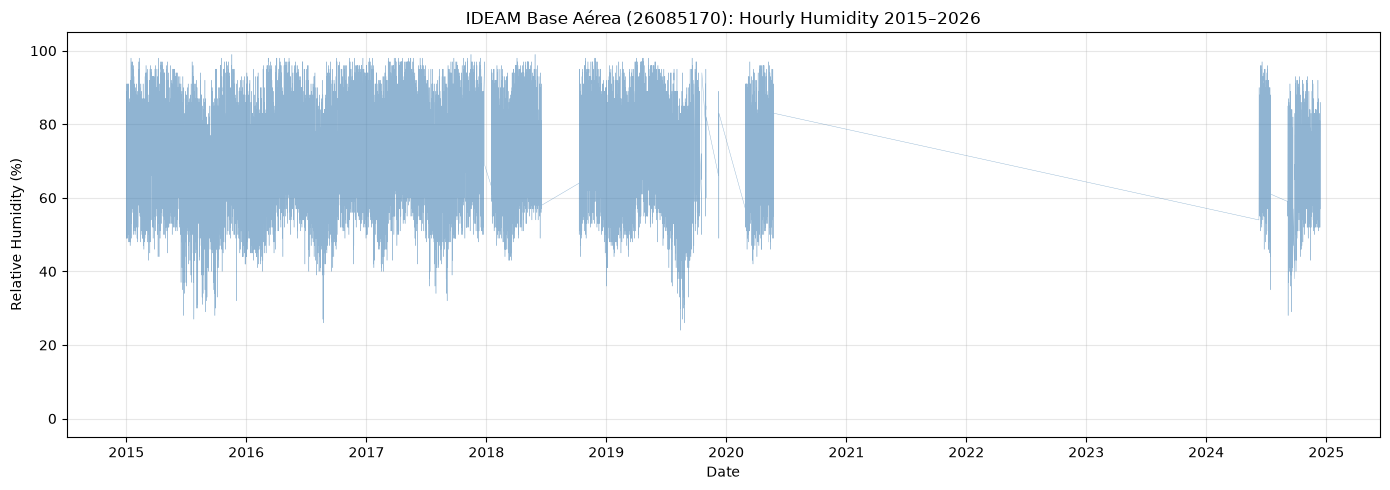

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_all["fecha"], df_all["valor"], linewidth=0.3, color="steelblue", alpha=0.6)
ax.set_xlabel("Date")
ax.set_ylabel("Relative Humidity (%)")
ax.set_title("IDEAM Base Aérea (26085170): Hourly Humidity 2015–2026")
ax.set_ylim(-5, 105)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Section 8 — Daily Aggregation

In [11]:
print(f"\n{'='*80}")
print("DAILY AGGREGATION")
print(f"{'='*80}")

df_with_index = df_all.set_index("fecha")
daily_max = df_with_index["valor"].resample("1D").max()
daily_min = df_with_index["valor"].resample("1D").min()
daily_mean = df_with_index["valor"].resample("1D").mean()
hourly_count = df_with_index["valor"].resample("1D").count()

df_daily = pd.DataFrame({
    "fecha": daily_max.index,
    "rh_max": daily_max.values,
    "rh_min": daily_min.values,
    "rh_mean": daily_mean.values,
    "hourly_count": hourly_count.values
})

df_daily["dayofyear"] = df_daily["fecha"].dt.dayofyear
df_daily["year"] = df_daily["fecha"].dt.year

total_days = len(df_daily)
days_24h = (hourly_count == 24).sum()
days_under_24 = (hourly_count < 24).sum()
days_under_18 = (hourly_count < 18).sum()
days_zero = (hourly_count == 0).sum()

print(f"\nTotal days in period: {total_days}")
print(f"Days with 24 hourly readings: {days_24h}")
print(f"Days with hourly_count < 24: {days_under_24}")
print(f"Days with hourly_count < 18 (unreliable): {days_under_18}")
print(f"Days with hourly_count == 0 (missing): {days_zero}")



DAILY AGGREGATION

Total days in period: 3635
Days with 24 hourly readings: 1386
Days with hourly_count < 24: 2249
Days with hourly_count < 18 (unreliable): 1910
Days with hourly_count == 0 (missing): 1802


## Section 9 — Save Output

In [12]:
output_dir = Path.cwd()
while output_dir != output_dir.parent:
    potential = output_dir / "shared" / "data" / "interim"
    if (potential.parent).is_dir():
        output_dir = potential
        output_dir.mkdir(exist_ok=True, parents=True)
        break
    output_dir = output_dir.parent
else:
    raise FileNotFoundError("Could not find shared/data directory")

ref_path = output_dir / "ideam_bonilla_aragon_daily.csv"
if not ref_path.exists():
    raise FileNotFoundError(f"Reference temperature file not found: {ref_path}")

ref_df = pd.read_csv(ref_path, nrows=0)
ref_cols = set(ref_df.columns)

print(f"\n{'='*80}")
print("SAVE OUTPUT")
print(f"{'='*80}")

print(f"\nReference (temperature) file columns: {sorted(ref_cols)}")
print(f"\nHumidity daily table columns: {list(df_daily.columns)}")

print(f"\nNote: Temperature table has t_max/t_min/t_mean;")
print(f"      Humidity table has rh_max/rh_min/rh_mean (different variable prefix)")
print(f"      Both share: fecha, hourly_count, dayofyear, year")

output_path = output_dir / "ideam_bonilla_humidity_daily.csv"
df_daily.to_csv(output_path, index=False)

if not output_path.exists():
    raise FileNotFoundError(f"Output file was not created: {output_path}")

print(f"\nSaved to: {output_path}")
print(f"Rows: {len(df_daily)}")
print(f"Columns: {list(df_daily.columns)}")



SAVE OUTPUT

Reference (temperature) file columns: ['dayofyear', 'fecha', 'hourly_count', 't_max', 't_mean', 't_min', 'year']

Humidity daily table columns: ['fecha', 'rh_max', 'rh_min', 'rh_mean', 'hourly_count', 'dayofyear', 'year']

Note: Temperature table has t_max/t_min/t_mean;
      Humidity table has rh_max/rh_min/rh_mean (different variable prefix)
      Both share: fecha, hourly_count, dayofyear, year

Saved to: /home/boris/PycharmProjects/CaliHeatWaves/shared/data/interim/ideam_bonilla_humidity_daily.csv
Rows: 3635
Columns: ['fecha', 'rh_max', 'rh_min', 'rh_mean', 'hourly_count', 'dayofyear', 'year']


## Section 10 — Summary

In [13]:
print(f"\n{'='*80}")
print("CONSOLIDATION SUMMARY")
print(f"{'='*80}")

print(f"\nFiles loaded:")
for fname in files_dict.keys():
    initial_count = len(dfs_raw[fname])
    print(f"  {fname}: {initial_count:,} rows")

total_before = sum(len(dfs_raw[fname]) for fname in dfs_raw.keys())
print(f"\nTotal rows before deduplication: {total_before:,}")
print(f"Duplicates removed: {unique_duplicate_fechas}")
print(f"Total rows after deduplication: {len(df_all):,}")

print(f"\nFull date range: {start_time} to {end_time}")
print(f"Overall coverage: {coverage_pct:.2f}%")

print(f"\nCoverage by year:")
for year in sorted(yearly_counts.index):
    print(f"  {year}: {yearly_pct[year]:6.1f}%")

print(f"\nPhysical plausibility:")
print(f"  Min humidity: {valid_values.min():.2f}%")
print(f"  Max humidity: {valid_values.max():.2f}%")
print(f"  Mean humidity: {valid_values.mean():.2f}%")
print(f"  Readings < 0%: {out_of_range_low}")
print(f"  Readings > 100%: {out_of_range_high}")
print(f"  Exactly 100% (saturation clipping): {saturation_100}")
print(f"  Exactly 0% (sensor fault): {saturation_0}")

print(f"\nDiurnal cycle:")
print(f"  Peak hour: {peak_hour:02d}h ({hourly_mean.max():.2f}%)")
print(f"  Trough hour: {trough_hour:02d}h ({hourly_mean.min():.2f}%)")
print(f"  Amplitude: {amplitude:.2f} percentage points")

print(f"\nDaily aggregates:")
print(f"  Total days: {total_days}")
print(f"  Days with 24 hourly: {days_24h}")
print(f"  Days with < 18 hourly: {days_under_18}")
print(f"  Days with 0 hourly: {days_zero}")

print(f"\nOutput file:")
print(f"  Path: {output_path}")
print(f"  Rows: {len(df_daily):,}")
print(f"\nConsolidation complete.")



CONSOLIDATION SUMMARY

Files loaded:
  descargaDhime_BaseAerea_Humedad_2015-2020.csv: 36,816 rows
  descargaDhime_BaseAereaHumedad_2020_2026.csv: 5,153 rows

Total rows before deduplication: 41,969
Duplicates removed: 0
Total rows after deduplication: 41,969

Full date range: 2015-01-01 00:00:00 to 2024-12-13 13:00:00
Overall coverage: 48.11%

Coverage by year:
  2015:   93.5%
  2016:   96.7%
  2017:   93.7%
  2018:   62.5%
  2019:   82.7%
  2020:   97.5%
  2024:   69.7%

Physical plausibility:
  Min humidity: 24.00%
  Max humidity: 99.00%
  Mean humidity: 72.33%
  Readings < 0%: 0
  Readings > 100%: 0
  Exactly 100% (saturation clipping): 0
  Exactly 0% (sensor fault): 0

Diurnal cycle:
  Peak hour: 06h (88.46%)
  Trough hour: 15h (55.09%)
  Amplitude: 33.37 percentage points

Daily aggregates:
  Total days: 3635
  Days with 24 hourly: 1386
  Days with < 18 hourly: 1910
  Days with 0 hourly: 1802

Output file:
  Path: /home/boris/PycharmProjects/CaliHeatWaves/shared/data/interim/idea